In [3]:
!pip install kaggle

In [4]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vedikavarmaa04","key":"15065650011fa39e2d462314f2f99ab0"}'}

In [5]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:14<00:00, 168MB/s]



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!ls

chest-xray-pneumonia.zip  drive  kaggle.json  sample_data


In [9]:
from zipfile import ZipFile
dataset = "/content/chest-xray-pneumonia.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset is extracted")


The dataset is extracted


In [10]:
!ls

chest_xray  chest-xray-pneumonia.zip  drive  kaggle.json  sample_data


In [11]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [12]:
import os

base_dir = "/content/chest_xray"

print(os.listdir(base_dir))

['val', 'train', 'test', 'chest_xray', '__MACOSX']


In [13]:
print(os.listdir("/content/chest_xray/train"))

['PNEUMONIA', 'NORMAL']


**Count** **images**

In [14]:
for folder in ["train", "val", "test"]:
  print(folder)

  for category in os.listdir(os.path.join(base_dir, folder)):
    path = os.path.join(base_dir, folder, category)

    print(category, len(os.listdir(path)))

train
PNEUMONIA 3875
NORMAL 1341
val
PNEUMONIA 8
NORMAL 8
test
PNEUMONIA 390
NORMAL 234


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Image preprocessing**

In [16]:
train_datagen = ImageDataGenerator(
    rescale =1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale=1./255)

**LOAD IMAGES**

In [17]:
train_generator = train_datagen.flow_from_directory(
    "/content/chest_xray/train",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

val_generator = test_datagen.flow_from_directory(
    "/content/chest_xray/val",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    "/content/chest_xray/test",
    target_size=(150,150),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


**BUILD CNN**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3), activation="relu",input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation="relu"))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
()

()

**Compile**

In [20]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

**Train**

**Train**

In [22]:
cnn_history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=10

)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 82s 463ms/step - accuracy: 0.7609 - loss: 0.4965 - val_accuracy: 0.7500 - val_loss: 0.7643
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 453ms/step - accuracy: 0.8530 - loss: 0.3359 - val_accuracy: 0.6875 - val_loss: 1.1000
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.8880 - loss: 0.2828 - val_accuracy: 0.6875 - val_loss: 0.7108
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 446ms/step - accuracy: 0.9018 - loss: 0.2605 - val_accuracy: 0.7500 - val_loss: 0.5915
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.8995 - loss: 0.2544 - val_accuracy: 0.6875 - val_loss: 0.8312
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 75s 457ms/step - accuracy: 0.9170 - loss: 0.2105 - val_accuracy: 0.8125 - val_loss: 0.5093
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 451ms/step - accuracy: 0.9218 - loss: 0.2061 - val_accuracy: 0.6250 - val_loss: 0.8622
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 448ms/step - accuracy: 0.9291 - loss: 0

**Evaluate**

In [23]:
loss, accuracy = model.evaluate(test_generator)

print("Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.8686 - loss: 0.4008
Accuracy: 0.8685897588729858


 **Accuracy graph** **

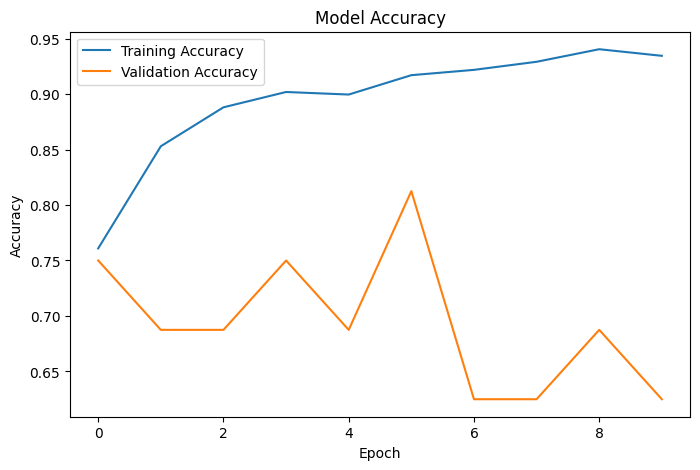

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

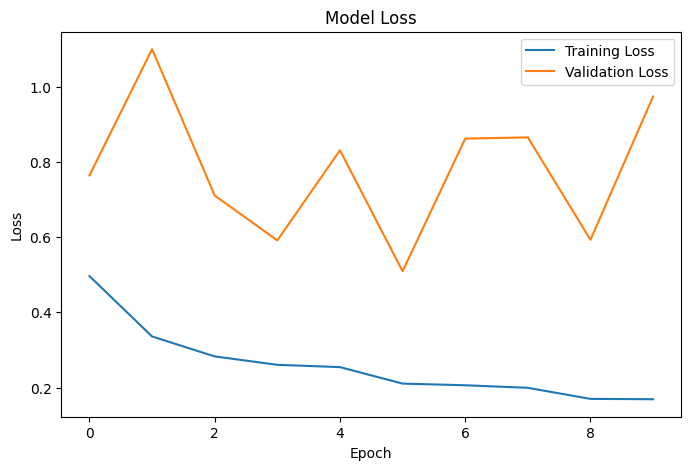

In [25]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
import pandas as pd
history_df = pd.DataFrame(cnn_history.history)
history_df

,accuracy,loss,val_accuracy,val_loss
0,0.760928,0.496475,0.7500,0.764323
1,0.852952,0.335870,0.6875,1.099979
2,0.888037,0.282831,0.6875,0.710826
3,0.901841,0.260487,0.7500,0.591496
4,0.899540,0.254388,0.6875,0.831181
5,0.916986,0.210544,0.8125,0.509287
6,0.921779,0.206126,0.6250,0.862190
7,0.929064,0.199327,0.6250,0.865511
8,0.940376,0.169868,0.6875,0.593030
9,0.934433,0.168988,0.6250,0.974233


In [27]:
history_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.760928,0.496475,0.7500,0.764323
1,0.852952,0.335870,0.6875,1.099979
2,0.888037,0.282831,0.6875,0.710826
3,0.901841,0.260487,0.7500,0.591496
4,0.899540,0.254388,0.6875,0.831181


**Predict a new X-ray**

In [28]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    "/content/chest_xray/test/NORMAL/IM-0001-0001.jpeg",
    target_size=(150,150),

)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255

prediction = model.predict(img_array)

if prediction > 0.5:
    print("PNEUMONIA (Not Safe)")
else:
    print("NORMAL (Safe)")



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
NORMAL (Safe)


**Test 5-10 images**

In [29]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder = "/content/chest_xray/test/NORMAL"

files = os.listdir(folder)[:5]

for file in files:

    img = image.load_img(
        os.path.join(folder,file),
        target_size=(150,150)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,0)
    img_array = img_array/255.0

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        print(file,"-> PNEUMONIA")
    else:
        print(file,"-> NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
NORMAL2-IM-0369-0001.jpeg -> NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
NORMAL2-IM-0327-0001.jpeg -> NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
IM-0105-0001.jpeg -> NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
IM-0089-0001.jpeg -> NORMAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
NORMAL2-IM-0060-0001.jpeg -> NORMAL


**for PNEUMONIA**

In [30]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np

folder = "/content/chest_xray/test/PNEUMONIA"

files = os.listdir(folder)[:5]

for file in files:

    img = image.load_img(
        os.path.join(folder, file),
        target_size=(150,150)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)

    if prediction[0][0] > 0.5:
        print(f"{file} --> PNEUMONIA")
    else:
        print(f"{file} --> NORMAL")

person80_bacteria_390.jpeg --> PNEUMONIA
person147_bacteria_705.jpeg --> PNEUMONIA
person71_virus_132.jpeg --> PNEUMONIA
person143_bacteria_687.jpeg --> PNEUMONIA
person128_bacteria_608.jpeg --> PNEUMONIA


**Now using ResNet50**

In [31]:
import tensorflow as tf

tf.keras.backend.clear_session()

In [32]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [33]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [34]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [35]:
train_generator = train_datagen.flow_from_directory(
    "/content/chest_xray/train",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

val_generator = val_datagen.flow_from_directory(
    "/content/chest_xray/val",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    "/content/chest_xray/test",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [36]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [37]:
base_model.trainable = False

In [38]:
x = base_model.output

In [39]:
x = GlobalAveragePooling2D()(x)

In [40]:
x = Dropout(0.5)(x)

In [41]:
predictions = Dense(
    1,
    activation="sigmoid"
)(x)

In [42]:
model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [43]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [44]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [46]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_resnet50.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [47]:
resnet_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 134s 737ms/step - accuracy: 0.8480 - loss: 0.3549 - val_accuracy: 0.8750 - val_loss: 0.3234
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 669ms/step - accuracy: 0.9248 - loss: 0.1860 - val_accuracy: 0.8750 - val_loss: 0.3300
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 671ms/step - accuracy: 0.9348 - loss: 0.1652 - val_accuracy: 0.8750 - val_loss: 0.2619
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9467 - loss: 0.1415 - val_accuracy: 0.9375 - val_loss: 0.1713
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9475 - loss: 0.1371 - val_accuracy: 0.9375 - val_loss: 0.1817
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 108s 665ms/step - accuracy: 0.9496 - loss: 0.1282 - val_accuracy: 0.8750 - val_loss: 0.2084
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 675ms/step - accuracy: 0.9484 - loss: 0.1315 - val_accuracy: 0.8750 - val_loss: 0.2172


In [48]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 251ms/step - accuracy: 0.8926 - loss: 0.2515
Test Loss: 0.2515206038951874
Test Accuracy: 0.8926281929016113
Accuracy (%): 89.26281929016113


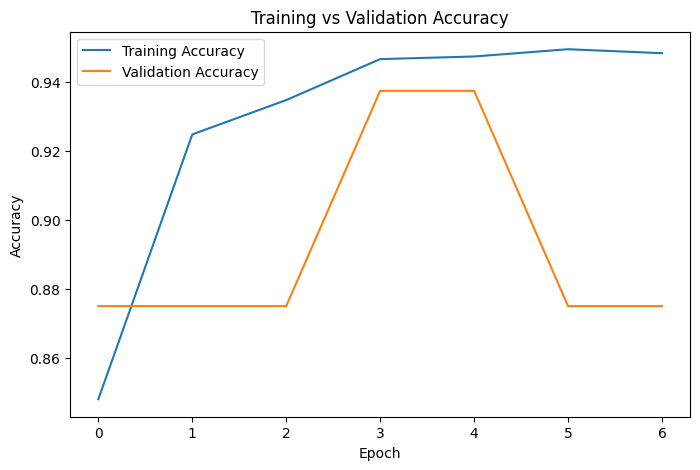

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(resnet_history.history["accuracy"], label="Training Accuracy")
plt.plot(resnet_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

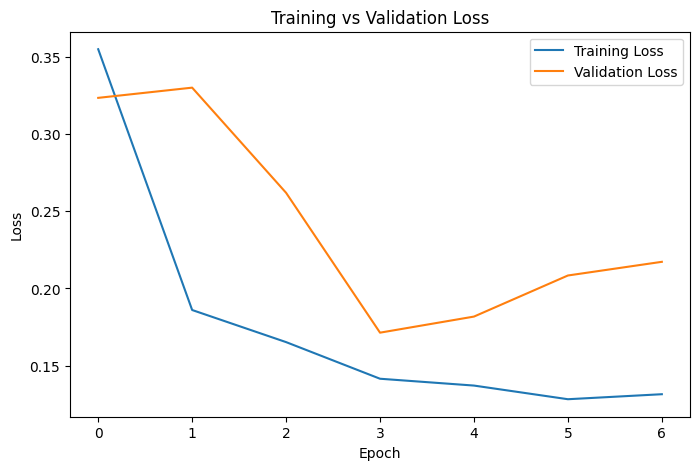

In [50]:
plt.figure(figsize=(8,5))

plt.plot(resnet_history.history["loss"], label="Training Loss")
plt.plot(resnet_history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [51]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

img = image.load_img(
    "/content/chest_xray/test/NORMAL/IM-0001-0001.jpeg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

print("Prediction Value:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Prediction: PNEUMONIA")
else:
    print("Prediction: NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction Value: 0.01107168
Prediction: NORMAL


**Compare CNN vs ResNet50**

In [61]:
cnn_accuracy = 86.85
resnet_accuracy = 89.26

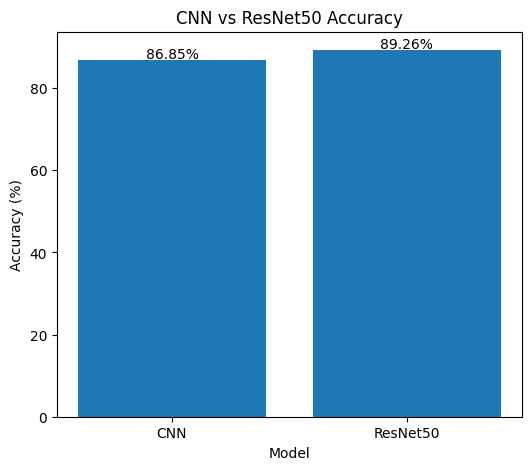

In [62]:
import matplotlib.pyplot as plt

models = ["CNN", "ResNet50"]
accuracies = [cnn_accuracy, resnet_accuracy]

plt.figure(figsize=(6,5))

plt.bar(models, accuracies)

plt.title("CNN vs ResNet50 Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha='center')

plt.show()

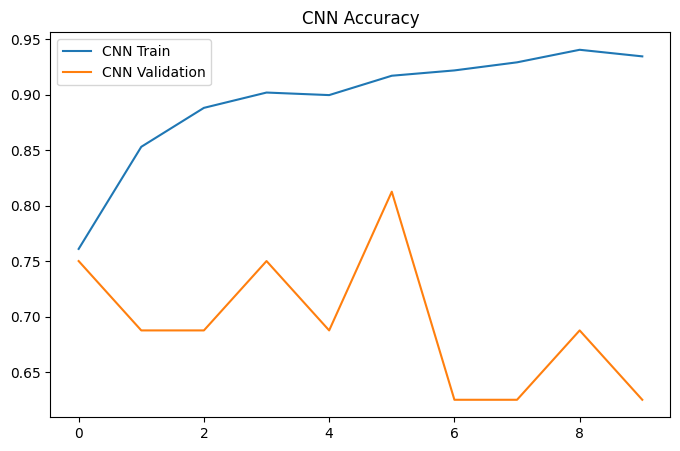

In [63]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history["accuracy"], label="CNN Train")
plt.plot(cnn_history.history["val_accuracy"], label="CNN Validation")

plt.legend()
plt.title("CNN Accuracy")
plt.show()

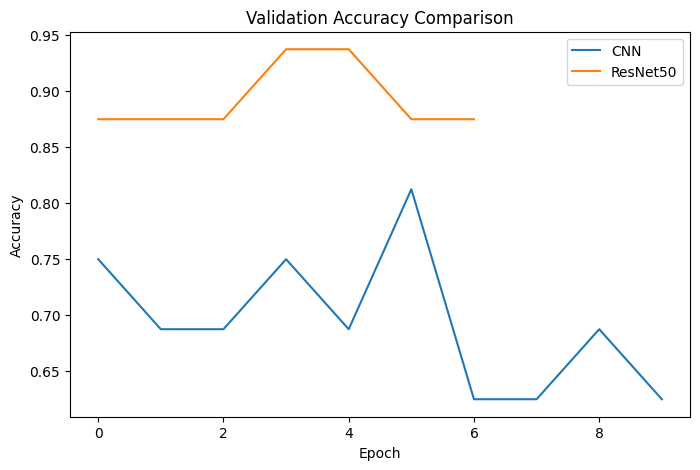

In [64]:
plt.figure(figsize=(8,5))

plt.plot(cnn_history.history["val_accuracy"], label="CNN")
plt.plot(resnet_history.history["val_accuracy"], label="ResNet50")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**Generate a Confusion Matrix**

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 506ms/step


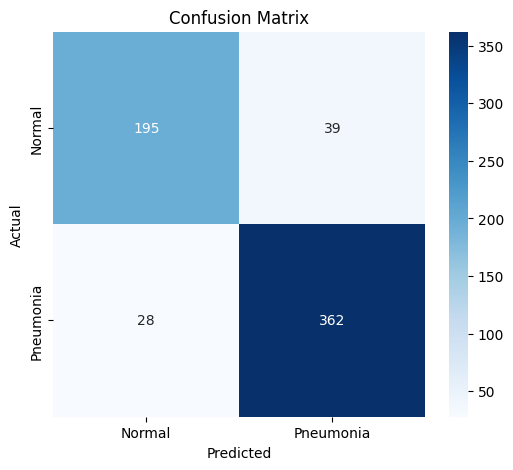

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Reset generator
test_generator.reset()

# Predictions
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Show Confidence**

In [67]:
score = prediction[0][0]

if score > 0.5:
    confidence = score * 100
    print(f"Prediction: PNEUMONIA")
    print(f"Confidence: {confidence:.2f}%")
else:
    confidence = (1-score) * 100
    print(f"Prediction: NORMAL")
    print(f"Confidence: {confidence:.2f}%")

Prediction: NORMAL
Confidence: 98.89%


**Classification Report**

In [68]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["NORMAL","PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.87      0.83      0.85       234
   PNEUMONIA       0.90      0.93      0.92       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.88       624
weighted avg       0.89      0.89      0.89       624



**Save the Best Model**

In [69]:
model.save("pneumonia_cnn.keras")

In [71]:
model.save("pneumonia_resnet50.keras")

In [72]:
from tensorflow.keras.models import load_model

model = load_model("pneumonia_cnn.keras")
model = load_model("pneumonia_resnet50.keras")

**Test Individual Images**

In [73]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

img = image.load_img(
    "/content/chest_xray/test/NORMAL/IM-0001-0001.jpeg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

prediction = model.predict(img_array)

print(prediction)

if prediction[0][0] > 0.5:
    print("PNEUMONIA")
else:
    print("NORMAL")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0.01107168]]
NORMAL


**For PNEUMONIA**

In [74]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

folder = "/content/chest_xray/test/PNEUMONIA"

files = os.listdir(folder)[:5]

for file in files:

    img = image.load_img(
        os.path.join(folder, file),
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)

    if prediction[0][0] > 0.5:
        print(f"{file} --> PNEUMONIA")
    else:
        print(f"{file} --> NORMAL")

person80_bacteria_390.jpeg --> PNEUMONIA
person147_bacteria_705.jpeg --> PNEUMONIA
person71_virus_132.jpeg --> PNEUMONIA
person143_bacteria_687.jpeg --> PNEUMONIA
person128_bacteria_608.jpeg --> PNEUMONIA


In [75]:
model.save("pneumonia_resnet50.keras")

In [76]:
model.save("pneumonia_cnn.keras")

**Download filr/model**

In [77]:
from google.colab import files

files.download("pneumonia_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
files.download("pneumonia_resnet50.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
plt.savefig("cnn_accuracy.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [80]:
plt.savefig("resnet_accuracy.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [81]:
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [82]:
files.download("cnn_accuracy.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
files.download("resnet_accuracy.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>